# Time series 14: Persistence + time-of-day delta

Model: **previous value + delta(hour)**. Things go up and down by time of day, so we learn an additive **delta per hour** (0–23) per channel from training: average change when the *target* time is that hour.

- **Predict**: \(\hat{y}_{t,j} = y_{t-1,j} + \delta_{j,h}\) where \(h\) is the hour of the *target* time \(t\).
- **Fit**: \(\delta_{j,h} = \text{mean}(y_{i,j} - y_{i-1,j})\) over training steps \(i\) where the hour at \(i\) is \(h\).
- Compare to **naive** (persistence only) and show results.

In [1]:
from pathlib import Path
import numpy as np
import pandas as pd

_root = Path.cwd().resolve()
if _root.name == "time_series":
    _root = _root.parent
DATA_PATH = _root / "data" / "transformed" / "transformed_data.parquet"
if not DATA_PATH.exists():
    DATA_PATH = DATA_PATH.with_suffix(".csv")
if not DATA_PATH.exists():
    raise FileNotFoundError(f"Transform data not found at {DATA_PATH}. Run task transform first.")

df = pd.read_parquet(DATA_PATH) if DATA_PATH.suffix == ".parquet" else pd.read_csv(DATA_PATH)
df = df.sort_values(["date", "hour"]).reset_index(drop=True)
df["datetime"] = pd.to_datetime(df["date"]) + pd.to_timedelta(df["hour"], unit="h")

freq_bands = sorted([c for c in df.columns if c not in ("date", "hour", "datetime")])
N = len(freq_bands)
Z = df[freq_bands].values.astype(np.float64)
Z = np.nan_to_num(Z, nan=0.0, posinf=0.0, neginf=0.0)
hours = df["hour"].values.astype(int)  # hour 0..23 for each row
T_total = Z.shape[0]

print(f"Loaded {len(df)} rows. Channels: {N}. Hours shape: {hours.shape}")

Loaded 9192 rows. Channels: 70. Hours shape: (9192,)


## Train / validation / test split and optional low-pass filter

In [2]:
train_ratio, val_ratio, test_ratio = 0.6, 0.1, 0.3
n_train = int(T_total * train_ratio)
n_val = int(T_total * val_ratio)
n_test = T_total - n_train - n_val

USE_LOWPASS = True
CUTOFF = 0.5
FILTER_ORDER = 3

def lowpass_per_channel(Z_mat, cutoff=0.5, order=3):
    from scipy.signal import butter, filtfilt
    normal_cutoff = min(float(cutoff), 0.99)
    b, a = butter(order, normal_cutoff, btype="low", analog=False)
    out = np.zeros_like(Z_mat)
    for j in range(Z_mat.shape[1]):
        out[:, j] = filtfilt(b, a, Z_mat[:, j])
    return out

if USE_LOWPASS:
    Z_full = lowpass_per_channel(Z, cutoff=CUTOFF, order=FILTER_ORDER)
    print(f"Applied low-pass filter (cutoff={CUTOFF}, order={FILTER_ORDER}).")
else:
    Z_full = Z.copy()

Z_train = Z_full[:n_train]
Z_val = Z_full[n_train : n_train + n_val]
Z_test = Z_full[n_train + n_val :]
hours_train = hours[:n_train]
test_start = n_train + n_val
print(f"Train: {n_train}, Val: {n_val}, Test: {n_test}")

Applied low-pass filter (cutoff=0.5, order=3).
Train: 5515, Val: 919, Test: 2758


## Fit delta per (channel, hour)

\(\delta_{j,h} = \text{mean}(y_{i,j} - y_{i-1,j})\) over training indices \(i \geq 1\) where \(\text{hour}(i) = h\).

In [3]:
n_hours = 24
delta = np.zeros((N, n_hours))
for j in range(N):
    for h in range(n_hours):
        # Training steps i where hour at i is h (target time)
        mask = (hours_train[1:] == h)
        if np.any(mask):
            diff = Z_train[1:, j] - Z_train[:-1, j]
            delta[j, h] = np.mean(diff[mask])
        # else delta[j,h] stays 0
print(f"Fitted delta shape: ({N}, {n_hours})")

Fitted delta shape: (70, 24)


## Test: predict = previous value + delta(hour of target)

In [4]:
pred_test = np.zeros((n_test, N), dtype=np.float64)
for t in range(n_test):
    prev_idx = test_start + t - 1 if t > 0 else test_start - 1
    h = hours[test_start + t]
    if h < 0 or h >= n_hours:
        h = 0
    for j in range(N):
        pred_test[t, j] = Z_full[prev_idx, j] + delta[j, h]

mape = np.mean(np.abs((Z_test - pred_test) / (np.abs(Z_test) + 1e-8))) * 100
rmse = np.sqrt(np.mean((Z_test - pred_test) ** 2))
mae = np.mean(np.abs(Z_test - pred_test))

print("Persistence + hour delta (test set):")
print(f"  MAPE = {mape:.4f}%")
print(f"  RMSE = {rmse:.4f}")
print(f"  MAE  = {mae:.4f}")

Persistence + hour delta (test set):
  MAPE = 14.9722%
  RMSE = 3.8167
  MAE  = 2.3127


## Naive baseline (persistence only)

In [5]:
pred_naive = np.zeros((n_test, N), dtype=np.float64)
for t in range(n_test):
    pred_naive[t] = Z_full[test_start + t - 1] if t > 0 else Z_full[test_start - 1]

mape_naive = np.mean(np.abs((Z_test - pred_naive) / (np.abs(Z_test) + 1e-8))) * 100
rmse_naive = np.sqrt(np.mean((Z_test - pred_naive) ** 2))
mae_naive = np.mean(np.abs(Z_test - pred_naive))

print("Naive (last value only):")
print(f"  MAPE = {mape_naive:.4f}%, RMSE = {rmse_naive:.4f}, MAE = {mae_naive:.4f}")

Naive (last value only):
  MAPE = 13.0105%, RMSE = 4.5277, MAE = 2.7672


## Comparison and plots

Comparison: Persistence+delta(hour) vs Naive
  MAPE: P+delta = 14.9722%,  Naive = 13.0105%
  RMSE: P+delta = 3.8167,  Naive = 4.5277
  MAE:  P+delta = 2.3127,  Naive = 2.7672


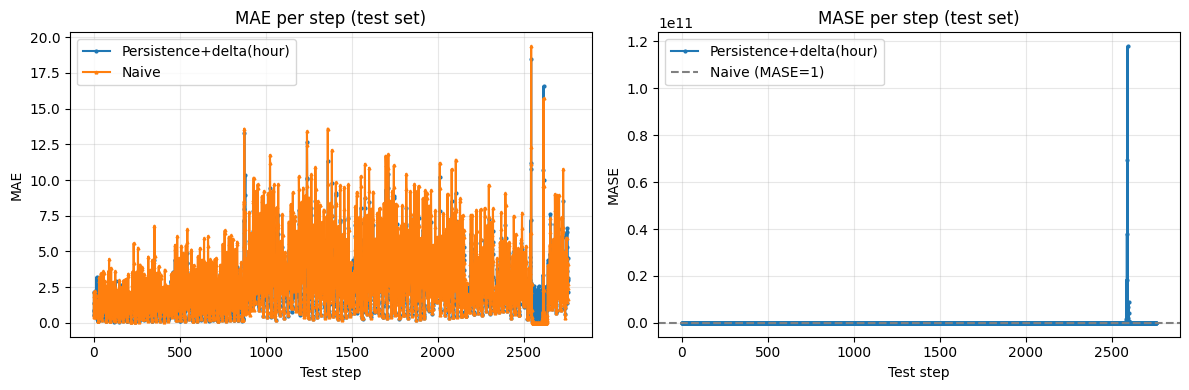

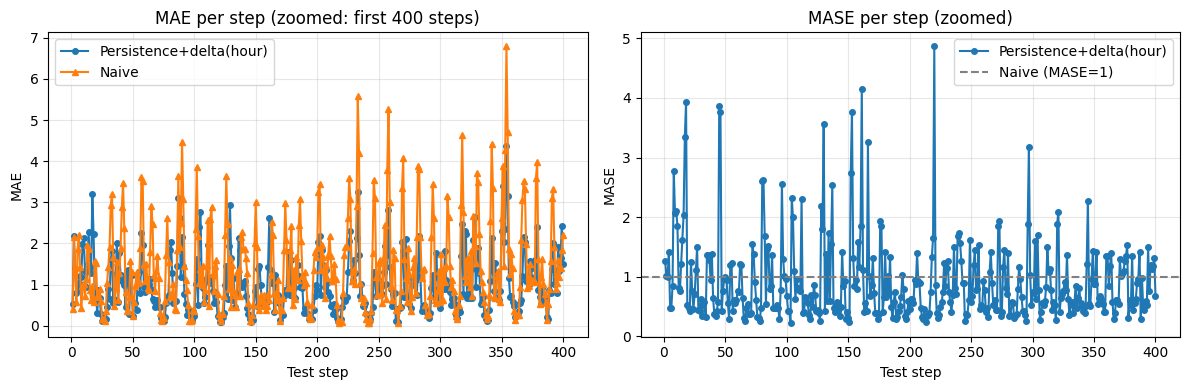

In [6]:
print("Comparison: Persistence+delta(hour) vs Naive")
print(f"  MAPE: P+delta = {mape:.4f}%,  Naive = {mape_naive:.4f}%")
print(f"  RMSE: P+delta = {rmse:.4f},  Naive = {rmse_naive:.4f}")
print(f"  MAE:  P+delta = {mae:.4f},  Naive = {mae_naive:.4f}")

import matplotlib.pyplot as plt
maes_pd = [float(np.mean(np.abs(Z_test[t] - pred_test[t]))) for t in range(n_test)]
maes_naive_d = [float(np.mean(np.abs(Z_test[t] - pred_naive[t]))) for t in range(n_test)]
mase_pd = [maes_pd[t] / (maes_naive_d[t] + 1e-12) for t in range(n_test)]
steps = list(range(1, n_test + 1))

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
ax1.plot(steps, maes_pd, "o-", label="Persistence+delta(hour)", markersize=2)
ax1.plot(steps, maes_naive_d, "^-", label="Naive", markersize=2)
ax1.set_xlabel("Test step")
ax1.set_ylabel("MAE")
ax1.set_title("MAE per step (test set)")
ax1.legend()
ax1.grid(True, alpha=0.3)
ax2.plot(steps, mase_pd, "o-", label="Persistence+delta(hour)", markersize=2)
ax2.axhline(1.0, color="gray", linestyle="--", label="Naive (MASE=1)")
ax2.set_xlabel("Test step")
ax2.set_ylabel("MASE")
ax2.set_title("MASE per step (test set)")
ax2.legend()
ax2.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

zoom_steps = min(400, n_test)
fig2, (ax3, ax4) = plt.subplots(1, 2, figsize=(12, 4))
ax3.plot(steps[:zoom_steps], maes_pd[:zoom_steps], "o-", label="Persistence+delta(hour)", markersize=4)
ax3.plot(steps[:zoom_steps], maes_naive_d[:zoom_steps], "^-", label="Naive", markersize=4)
ax3.set_xlabel("Test step")
ax3.set_ylabel("MAE")
ax3.set_title(f"MAE per step (zoomed: first {zoom_steps} steps)")
ax3.legend()
ax3.grid(True, alpha=0.3)
ax4.plot(steps[:zoom_steps], mase_pd[:zoom_steps], "o-", label="Persistence+delta(hour)", markersize=4)
ax4.axhline(1.0, color="gray", linestyle="--", label="Naive (MASE=1)")
ax4.set_xlabel("Test step")
ax4.set_ylabel("MASE")
ax4.set_title(f"MASE per step (zoomed)")
ax4.legend()
ax4.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()